In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

Exponential Fit: a = 5.209, b = 0.422
Power Law Fit:   a = 4.087, b = 1.112


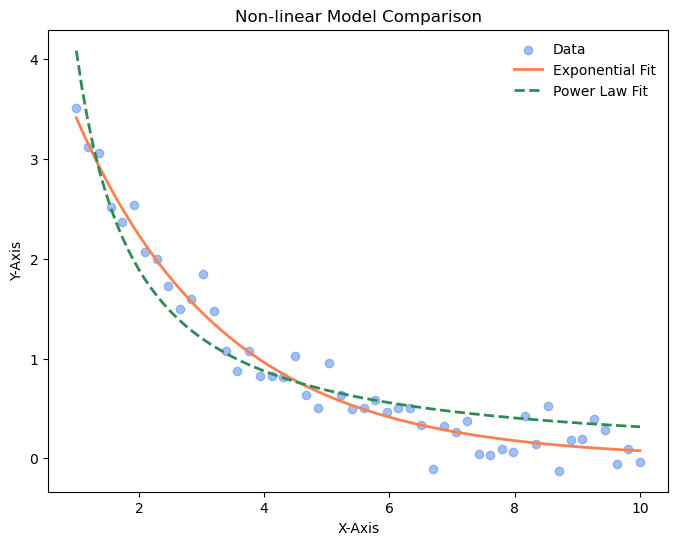

In [7]:
def exponential_model(x, a, b):
    return a * np.exp(-b * x)  

def power_law_model(x, a, b):
    return a / (x**b)  

def main():
    x_data = np.linspace(1, 10, 50) 
    y_true = 5 * np.exp(-0.4 * x_data)
    y_data = y_true + np.random.normal(scale=0.2, size=len(x_data))

    popt_exp, pcov_exp = curve_fit(exponential_model, x_data, y_data, p0=[5, 0.5])
    popt_pow, pcov_pow = curve_fit(power_law_model, x_data, y_data, p0=[5, 1.0])

    print(f"Exponential Fit: a = {popt_exp[0]:.3f}, b = {popt_exp[1]:.3f}")
    print(f"Power Law Fit:   a = {popt_pow[0]:.3f}, b = {popt_pow[1]:.3f}")

    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, color='cornflowerblue', alpha=0.6, label='Data')
    
    x_fit = np.linspace(1, 10, 100)
    plt.plot(x_fit, exponential_model(x_fit, *popt_exp), color='coral', 
             linewidth=2, label='Exponential Fit')
    plt.plot(x_fit, power_law_model(x_fit, *popt_pow), color='seagreen', 
             linestyle='--', linewidth=2, label='Power Law Fit')

    plt.xlabel('X-Axis')
    plt.ylabel('Y-Axis')
    plt.legend(loc='upper right', frameon=False)
    plt.title('Non-linear Model Comparison')
    
    plt.savefig('model_fits.pdf', format='pdf', bbox_inches='tight')
    plt.show()

if __name__ == "__main__":
    main()